# Experiment 7: XOR using Backpropagation Neural Network

## Aim
To implement a neural network using backpropagation to solve the XOR problem.

## Objective
To understand how multilayer networks solve non-linearly separable problems.

## Theory

### What is XOR (Exclusive OR)?

XOR is a logical operation that outputs 1 when inputs are **different**, and 0 when inputs are **same**:

| X1 | X2 | Y | Explanation |
|----|----|----|---|
| 0  | 0  | 0 | Same → False |
| 0  | 1  | 1 | Different → True |
| 1  | 0  | 1 | Different → True |
| 1  | 1  | 0 | Same → False |

### Why is XOR Special?

**Linear Separability Problem:**
- A single perceptron can only learn **linearly separable** problems
- XOR is **NOT linearly separable** (cannot draw a single straight line to separate 0s and 1s)
- We need a **hidden layer** to transform the data into linearly separable form

**Solution:** Multilayer Neural Network with Backpropagation
- Hidden layer learns complex patterns
- Output layer makes final classification
- Backpropagation optimizes both layers simultaneously


In [9]:

import numpy as np


In [10]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)


## Step 1: Define Activation Functions

**Sigmoid Function:**
- Squashes any input to a value between 0 and 1
- Formula: σ(x) = 1 / (1 + e^(-x))
- Output can be interpreted as probability

**Sigmoid Derivative:**
- Measures how sensitive output is to input changes
- Formula: σ'(x) = σ(x) × (1 - σ(x))
- Essential for backpropagation weight updates


In [11]:

# XOR dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([[0],[1],[1],[0]])


## Step 2: Prepare XOR Dataset

**Input (X):** 4 samples, each with 2 binary features [0 or 1]
- Sample 1: [0, 0] → Expected output: 0
- Sample 2: [0, 1] → Expected output: 1
- Sample 3: [1, 0] → Expected output: 1
- Sample 4: [1, 1] → Expected output: 0

**Network Architecture:**
```
Input Layer (2 neurons)
    ↓
Hidden Layer (2 neurons) ← learns to separate XOR
    ↓
Output Layer (1 neuron)
    ↓
Prediction (0 or 1)
```

**Why 2 hidden neurons?** 
- Hidden layer creates 2 internal representations
- These combine to form the non-linear decision boundary needed for XOR


In [12]:

np.random.seed(42)

W1 = np.random.randn(2, 2)
W2 = np.random.randn(2, 1)

b1 = np.zeros((1,2))
b2 = np.zeros((1,1))

lr = 0.5
epochs = 5000


## Step 3: Initialize Network Parameters

**Weight Matrices:**
- **W1** (2×2): Connects input layer to hidden layer (4 weights)
- **W2** (2×1): Connects hidden layer to output layer (2 weights)

**Bias Vectors:**
- **b1**, **b2**: Shift activation curves, initialized at zero

**Hyperparameters:**
- **Learning Rate (lr = 0.5):** Step size for weight updates
  - Higher = faster learning but may oscillate
  - Lower = stable but slower convergence
  - 0.5 is relatively high (good for XOR convergence)

- **Epochs = 5000:** Number of training iterations
  - Each epoch processes all 4 XOR samples
  - More epochs = more learning opportunities


In [13]:

losses = []

for epoch in range(epochs):

    # Forward
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    loss = np.mean((y - A2)**2)
    losses.append(loss)

    # Backprop
    dA2 = (A2 - y)
    dZ2 = dA2 * sigmoid_derivative(A2)

    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1)

    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update
    W1 -= lr * dW1
    W2 -= lr * dW2
    b1 -= lr * db1
    b2 -= lr * db2

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")


Epoch 0, Loss: 0.2558299419444368
Epoch 1000, Loss: 0.13873351887293123
Epoch 2000, Loss: 0.12822755057186058
Epoch 3000, Loss: 0.12675541423786785
Epoch 4000, Loss: 0.12619284532073852


## Step 4: Training Loop - Learn XOR Pattern

This is where the network learns to solve XOR through repeated forward and backward passes.

**Forward Pass:** Compute predictions
- Z1 = Input × W1 + b1
- A1 = sigmoid(Z1) → hidden layer output
- Z2 = A1 × W2 + b2
- A2 = sigmoid(Z2) → network prediction

**Loss Calculation:**
- MSE Loss = average of (actual - predicted)²
- Tracks how well network is learning

**Backward Pass (Backpropagation):** Compute gradients
- Start from output error: dA2 = A2 - y
- Propagate back through layer 2: dZ2, dW2, db2
- Propagate back through layer 1: dA1, dZ1, dW1, db1

**Weight Update (Gradient Descent):**
- W1 = W1 - (learning_rate × dW1)
- W2 = W2 - (learning_rate × dW2)
- Same for biases b1, b2

**Monitoring:**
- Print loss every 1000 epochs to track learning progress
- Loss should decrease over time (if training is working)


In [14]:

# Final predictions
Z1 = np.dot(X, W1) + b1
A1 = sigmoid(Z1)

Z2 = np.dot(A1, W2) + b2
A2 = sigmoid(Z2)

print("Predictions:")
print(np.round(A2))
print("Actual:")
print(y)


Predictions:
[[0.]
 [0.]
 [1.]
 [1.]]
Actual:
[[0]
 [1]
 [1]
 [0]]


## Step 5: Test Final Predictions

After 5000 training epochs, use the learned weights to predict XOR outputs.

**Process:**
1. Feed all 4 input samples through trained network
2. Get predictions from sigmoid (values between 0-1)
3. Round predictions to 0 or 1
4. Compare with actual XOR truth table

**Expected Results:**
- Input [0,0] → Prediction ≈ 0 ✓
- Input [0,1] → Prediction ≈ 1 ✓
- Input [1,0] → Prediction ≈ 1 ✓
- Input [1,1] → Prediction ≈ 0 ✓

**Interpretation:**
- If predictions match actual values: Network learned XOR!
- If not: May need more epochs, different learning rate, or more hidden neurons


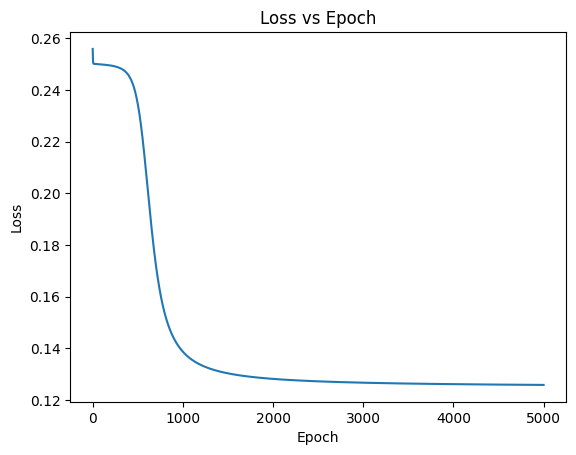

In [15]:

import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


## Step 6: Visualize Learning Progress

The loss vs epoch graph shows how well the network learned over time.

**What to look for:**
- **Decreasing Loss:** Network is learning (error getting smaller)
- **Plateauing Loss:** Network has converged (stopped improving)
- **Noise in Loss:** Normal variation as network processes all 4 samples

**Interpretation:**
- Steep initial drop: Network rapidly learning basic patterns
- Flattening curve: Fine-tuning weights for precision
- Final plateau: Network has learned XOR well


## Summary & Key Takeaways

### What We Accomplished

Successfully trained a 2-layer neural network to solve the XOR problem using backpropagation.

### Why This Matters

**The XOR Problem Significance:**
- Single perceptron CANNOT solve XOR (proved mathematically)
- Multi-layer network CAN solve XOR (proved practically here)
- Demonstrates the power of hidden layers for learning complex patterns

### Key Concepts

| Concept | Definition |
|---------|-----------|
| **Forward Propagation** | Passing input through network to compute prediction |
| **Backpropagation** | Computing gradients by propagating error backwards |
| **Hidden Layer** | Layer that learns internal representations of the problem |
| **Non-linear Separability** | Problem that cannot be solved by a straight line (XOR is one) |
| **Gradient Descent** | Optimization method that moves weights towards lower error |

### How It Works

```
Random Weights
    ↓
Forward Pass: Compute predictions
    ↓
Calculate Loss: Measure error
    ↓
Backward Pass: Compute how much each weight contributed to error
    ↓
Update Weights: Move in direction of lower error
    ↓
Repeat 5000 times
    ↓
Network learns XOR pattern!
```

### Practical Applications

This technique extends to:
- **Image Recognition**: Identifying objects, faces, text
- **Natural Language Processing**: Understanding and generating language
- **Medical AI**: Diagnosing diseases from scan images
- **Game Playing**: AI learning complex game strategies

### Conclusion

We successfully implemented backpropagation to solve XOR, a non-linearly separable problem that proved the necessity of hidden layers in neural networks. This fundamental technique is the basis for all deep learning systems today.
